In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [14]:
# -------------------------------
# Scikit-Learn (Machine Learning utilities)
# -------------------------------
from sklearn.model_selection import train_test_split
#  Splits the dataset into training and testing sets to evaluate model performance.

from sklearn.preprocessing import LabelEncoder, StandardScaler
# LabelEncoder: Converts categorical labels (e.g., "cat", "dog") into numeric values.
# StandardScaler: Normalizes/standardizes numerical features so they have mean=0 and variance=1.

from sklearn.linear_model import Perceptron
# A simple linear classifier (single-layer neural network). Good for binary classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# accuracy_score: Measures how many predictions are correct.
# classification_report: Shows precision, recall, and F1-score for each class.
# confusion_matrix: Shows where the model is making correct vs wrong predictions.

# -------------------------------
# TensorFlow / Keras (Deep Learning utilities)
# -------------------------------
import tensorflow as tf

from tensorflow.keras.models import Sequential
# Lets you build a neural network layer-by-layer in a linear fashion.

from tensorflow.keras.layers import Dense
# Fully connected layer (every neuron connects to every neuron in the next layer).

from tensorflow.keras.layers import Dropout
# Randomly drops some neurons during training to prevent overfitting.

from tensorflow.keras.utils import to_categorical
# 👉 Converts class labels (like 0, 1, 2) into one-hot encoded format (e.g., [1,0,0], [0,1,0]).

In [5]:
df = pd.read_csv("iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [8]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
 5   species_id    150 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


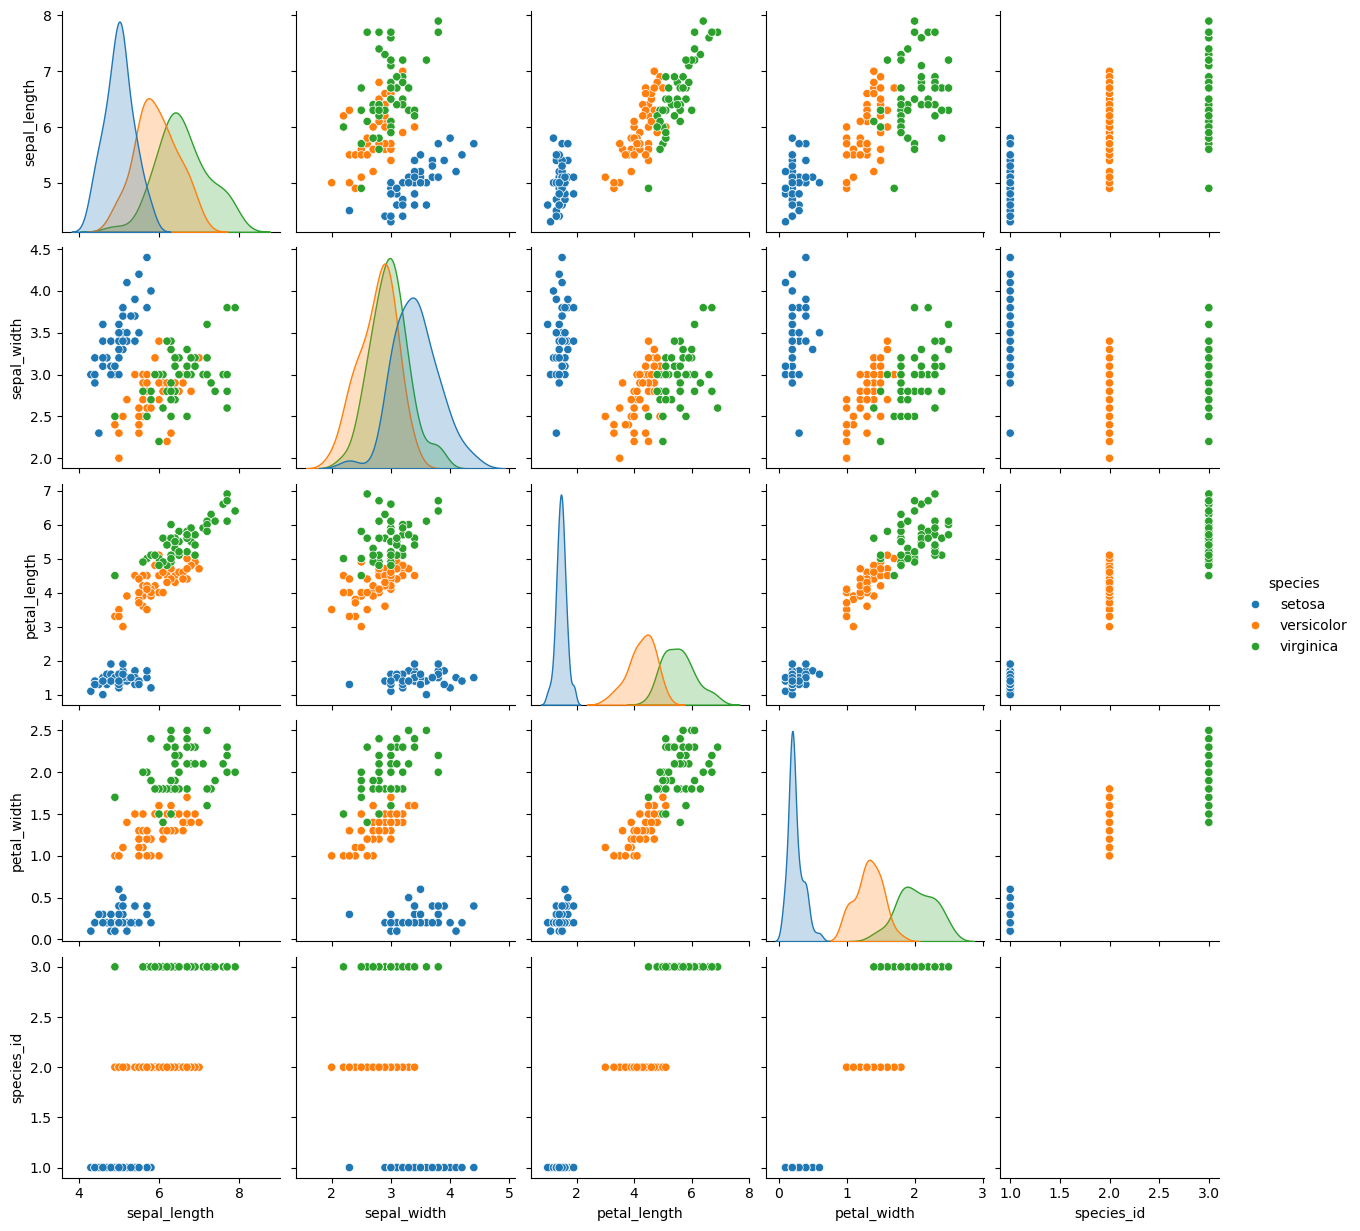

In [10]:
sns.pairplot(df, hue="species")

In [12]:
X = df.drop(columns = ["species_id", "species"], axis = 1);
y = df["species"]

In [15]:
encoder = LabelEncoder()
y_int = encoder.fit_transform(y)

In [16]:
y_int

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y_int, test_size=0.2, random_state=42, stratify=y_int )

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
per = Perceptron(max_iter=1000, random_state=42)
per.fit(X_train_scaled, y_train)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,42


In [22]:
y_pred_percep = per.predict(X_test_scaled)

In [23]:
accuracy_score(y_test, y_pred_percep)

0.8666666666666667

In [25]:
print(classification_report(y_test, y_pred_percep))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       0.88      0.70      0.78        10
           2       0.90      0.90      0.90        10

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.86        30
weighted avg       0.87      0.87      0.86        30



In [34]:
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

In [35]:
y_train_cat

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0

In [29]:
model = Sequential([
    Dense(16, input_dim = 4, activation="relu"),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

In [32]:
model.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

In [36]:
history = model.fit(X_train_scaled, y_train_cat, epochs=100, batch_size=8, validation_split=0.2, verbose=1)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.1771 - loss: 1.1789 - val_accuracy: 0.1667 - val_loss: 1.1795
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2917 - loss: 1.1395 - val_accuracy: 0.2500 - val_loss: 1.1472
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3333 - loss: 1.0977 - val_accuracy: 0.2500 - val_loss: 1.1108
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3854 - loss: 1.0582 - val_accuracy: 0.2917 - val_loss: 1.0740
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5208 - loss: 1.0165 - val_accuracy: 0.5000 - val_loss: 1.0394
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6042 - loss: 0.9765 - val_accuracy: 0.5417 - val_loss: 1.0040
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6562 - loss: 0.9356 - val_accuracy: 0.5833 - val_loss: 0.9667
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6667 - loss: 0.8932 - val_accuracy: 0.

In [37]:
loss, acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(acc)

0.9666666388511658


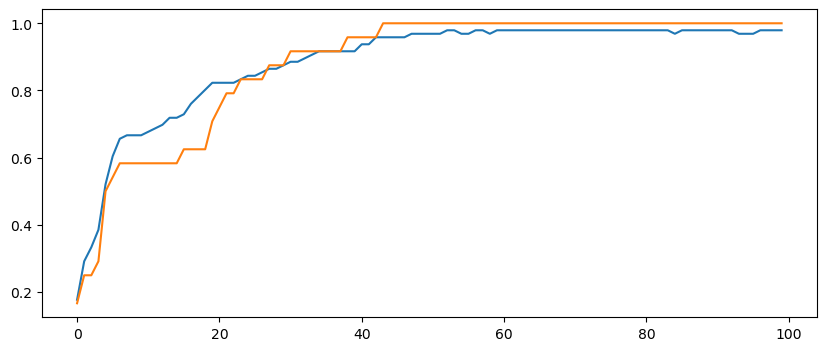

In [38]:
plt.figure(figsize = (10,4))
plt.plot(history.history['accuracy'],label = "train Acc")
plt.plot(history.history['val_accuracy'],label = "val Acc")